In [20]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [21]:
import pandas as pd
import numpy as np

csv_path = "/content/drive/MyDrive/Maternal Health Risk Data Set.csv"

df = pd.read_csv(csv_path)

df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [23]:
df.shape

(1014, 7)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


In [25]:
df.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


In [26]:
df.isnull().sum()

,0
Age,0
SystolicBP,0
DiastolicBP,0
BS,0
BodyTemp,0
HeartRate,0
RiskLevel,0


In [27]:
df.duplicated().sum()

np.int64(562)

In [28]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.head()

,age,systolicbp,diastolicbp,bs,bodytemp,heartrate,risklevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [29]:
df["risklevel"] = df["risklevel"].str.strip().str.lower()

df["risklevel"].value_counts()

,count
risklevel,
low risk,406
mid risk,336
high risk,272


In [44]:
#For healthcare analytics, I recommend keeping the original data for dashboard counts, but also creating a deduplicated version for modeling.
df_original = df.copy()

df_clean = df.drop_duplicates().copy()

print("Original shape:", df_original.shape)
print("Cleaned shape:", df_clean.shape)

##Use df_clean for most analysis.
df = df_clean.copy()

Original shape: (452, 14)
Cleaned shape: (452, 14)


In [36]:
def age_group(age):
    if age < 20:
        return "Under 20"
    elif age <= 29:
        return "20-29"
    elif age <= 34:
        return "30-34"
    elif age <= 39:
        return "35-39"
    else:
        return "40+"

df["age_group"] = df["age"].apply(age_group)

df[["age", "age_group"]].head()

,age,age_group
0,25,20-29
1,35,35-39
2,29,20-29
3,30,30-34
4,35,35-39


In [37]:
def bp_category(row):
    systolic = row["systolicbp"]
    diastolic = row["diastolicbp"]

    if systolic >= 140 or diastolic >= 90:
        return "High BP"
    elif systolic >= 120 or diastolic >= 80:
        return "Elevated BP"
    else:
        return "Normal BP"

df["bp_category"] = df.apply(bp_category, axis=1)

df["bp_category"].value_counts()

,count
bp_category,
Normal BP,179
Elevated BP,155
High BP,118


In [38]:
def blood_sugar_category(bs):
    if bs >= 11:
        return "High Blood Sugar"
    elif bs >= 7.8:
        return "Elevated Blood Sugar"
    else:
        return "Normal Blood Sugar"

df["blood_sugar_category"] = df["bs"].apply(blood_sugar_category)

df["blood_sugar_category"].value_counts()

,count
blood_sugar_category,
Normal Blood Sugar,301
Elevated Blood Sugar,83
High Blood Sugar,68


In [39]:
def temp_category(temp):
    if temp >= 100.4:
        return "Fever"
    elif temp < 97:
        return "Low Temperature"
    else:
        return "Normal Temperature"

df["bodytemp_category"] = df["bodytemp"].apply(temp_category)

df["bodytemp_category"].value_counts()

,count
bodytemp_category,
Normal Temperature,372
Fever,80


In [40]:
def heart_rate_category(hr):
    if hr > 100:
        return "High Heart Rate"
    elif hr < 60:
        return "Low Heart Rate"
    else:
        return "Normal Heart Rate"

df["heartrate_category"] = df["heartrate"].apply(heart_rate_category)

df["heartrate_category"].value_counts()

,count
heartrate_category,
Normal Heart Rate,451
Low Heart Rate,1


In [41]:
risk_mapping = {
    "low risk": 1,
    "mid risk": 2,
    "high risk": 3
}

df["risk_score"] = df["risklevel"].map(risk_mapping)

df["high_risk_flag"] = df["risklevel"].apply(
    lambda x: 1 if x == "high risk" else 0
)

df[["risklevel", "risk_score", "high_risk_flag"]].head()

,risklevel,risk_score,high_risk_flag
0,high risk,3,1
1,high risk,3,1
2,high risk,3,1
3,high risk,3,1
4,low risk,1,0


In [43]:
#High Risk
risk_summary = df.groupby("risklevel").agg(
    total_patients=("risklevel", "count"),
    avg_age=("age", "mean"),
    avg_systolic_bp=("systolicbp", "mean"),
    avg_diastolic_bp=("diastolicbp", "mean"),
    avg_blood_sugar=("bs", "mean"),
    avg_body_temp=("bodytemp", "mean"),
    avg_heart_rate=("heartrate", "mean")
).reset_index()

risk_summary


#High Risk by Age Group
high_risk_by_age = df.groupby("age_group").agg(
    total_patients=("risklevel", "count"),
    high_risk_patients=("high_risk_flag", "sum")
).reset_index()

high_risk_by_age["high_risk_percent"] = (
    high_risk_by_age["high_risk_patients"] / high_risk_by_age["total_patients"] * 100
).round(2)

high_risk_by_age.sort_values("high_risk_percent", ascending=False)

# High Risk By Blood Pressure
high_risk_by_bp = df.groupby("bp_category").agg(
    total_patients=("risklevel", "count"),
    high_risk_patients=("high_risk_flag", "sum")
).reset_index()

high_risk_by_bp["high_risk_percent"] = (
    high_risk_by_bp["high_risk_patients"] / high_risk_by_bp["total_patients"] * 100
).round(2)

high_risk_by_bp.sort_values("high_risk_percent", ascending=False)

#High risk by blood sugar
high_risk_by_bs = df.groupby("blood_sugar_category").agg(
    total_patients=("risklevel", "count"),
    high_risk_patients=("high_risk_flag", "sum")
).reset_index()

high_risk_by_bs["high_risk_percent"] = (
    high_risk_by_bs["high_risk_patients"] / high_risk_by_bs["total_patients"] * 100
).round(2)

high_risk_by_bs.sort_values("high_risk_percent", ascending=False)



,blood_sugar_category,total_patients,high_risk_patients,high_risk_percent
1,High Blood Sugar,68,57,83.82
0,Elevated Blood Sugar,83,25,30.12
2,Normal Blood Sugar,301,30,9.97


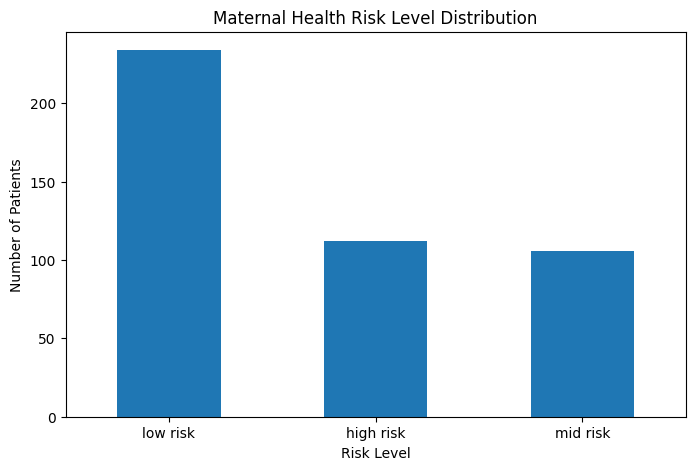

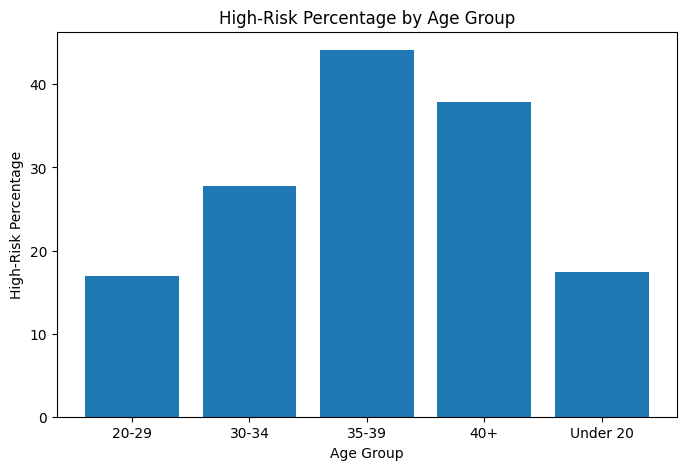

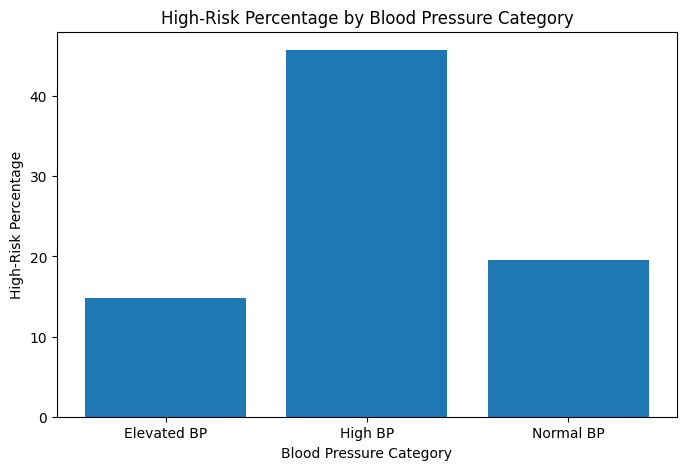

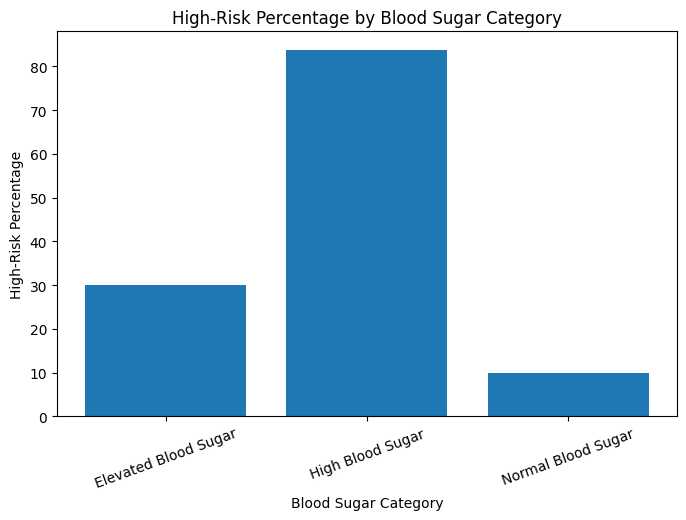

In [45]:
import matplotlib.pyplot as plt


#Risk level distribution

risk_counts = df["risklevel"].value_counts()

plt.figure(figsize=(8, 5))
risk_counts.plot(kind="bar")
plt.title("Maternal Health Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()


#High Risk by Age group
plt.figure(figsize=(8, 5))
plt.bar(high_risk_by_age["age_group"], high_risk_by_age["high_risk_percent"])
plt.title("High-Risk Percentage by Age Group")
plt.xlabel("Age Group")
plt.ylabel("High-Risk Percentage")
plt.xticks(rotation=0)
plt.show()

#High risk by blood pressure category
plt.figure(figsize=(8, 5))
plt.bar(high_risk_by_bp["bp_category"], high_risk_by_bp["high_risk_percent"])
plt.title("High-Risk Percentage by Blood Pressure Category")
plt.xlabel("Blood Pressure Category")
plt.ylabel("High-Risk Percentage")
plt.xticks(rotation=0)
plt.show()

#High risk by blood sugar category
plt.figure(figsize=(8, 5))
plt.bar(high_risk_by_bs["blood_sugar_category"], high_risk_by_bs["high_risk_percent"])
plt.title("High-Risk Percentage by Blood Sugar Category")
plt.xlabel("Blood Sugar Category")
plt.ylabel("High-Risk Percentage")
plt.xticks(rotation=20)
plt.show()

In [48]:
import sqlite3

conn = sqlite3.connect("maternal_health.db")

df.to_sql("maternal_health", conn, if_exists="replace", index=False)

#SQL query: risk summary
query = """
SELECT
    risklevel,
    COUNT(*) AS total_patients,
    ROUND(AVG(age), 1) AS avg_age,
    ROUND(AVG(systolicbp), 1) AS avg_systolic_bp,
    ROUND(AVG(diastolicbp), 1) AS avg_diastolic_bp,
    ROUND(AVG(bs), 2) AS avg_blood_sugar,
    ROUND(AVG(bodytemp), 1) AS avg_body_temp,
    ROUND(AVG(heartrate), 1) AS avg_heart_rate
FROM maternal_health
GROUP BY risklevel
ORDER BY total_patients DESC;
"""

pd.read_sql(query, conn)


#SQL query: high-risk percentage by age group

query = """
SELECT
    age_group,
    COUNT(*) AS total_patients,
    SUM(high_risk_flag) AS high_risk_patients,
    ROUND(SUM(high_risk_flag) * 100.0 / COUNT(*), 2) AS high_risk_percent
FROM maternal_health
GROUP BY age_group
ORDER BY high_risk_percent DESC;
"""

pd.read_sql(query, conn)

#SQL query: high-risk percentage by BP category
query = """
SELECT
    bp_category,
    COUNT(*) AS total_patients,
    SUM(high_risk_flag) AS high_risk_patients,
    ROUND(SUM(high_risk_flag) * 100.0 / COUNT(*), 2) AS high_risk_percent
FROM maternal_health
GROUP BY bp_category
ORDER BY high_risk_percent DESC;
"""

pd.read_sql(query, conn)

#SQL query: high-risk percentage by blood sugar category
query = """
SELECT
    blood_sugar_category,
    COUNT(*) AS total_patients,
    SUM(high_risk_flag) AS high_risk_patients,
    ROUND(SUM(high_risk_flag) * 100.0 / COUNT(*), 2) AS high_risk_percent
FROM maternal_health
GROUP BY blood_sugar_category
ORDER BY high_risk_percent DESC;
"""

pd.read_sql(query, conn)



,blood_sugar_category,total_patients,high_risk_patients,high_risk_percent
0,High Blood Sugar,68,57,83.82
1,Elevated Blood Sugar,83,25,30.12
2,Normal Blood Sugar,301,30,9.97


In [49]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

model_df = df.copy()

label_encoder = LabelEncoder()
model_df["risklevel_encoded"] = label_encoder.fit_transform(model_df["risklevel"])

X = model_df[["age", "systolicbp", "diastolicbp", "bs", "bodytemp", "heartrate"]]
y = model_df["risklevel_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print()
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Accuracy: 0.571

              precision    recall  f1-score   support

   high risk       0.94      0.70      0.80        23
    low risk       0.59      0.70      0.64        47
    mid risk       0.17      0.14      0.15        21

    accuracy                           0.57        91
   macro avg       0.57      0.51      0.53        91
weighted avg       0.58      0.57      0.57        91



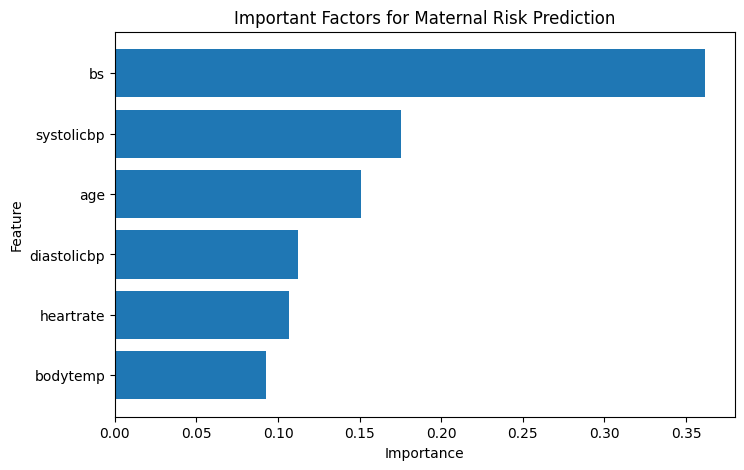

In [50]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance


plt.figure(figsize=(8, 5))
plt.barh(feature_importance["feature"], feature_importance["importance"])
plt.title("Important Factors for Maternal Risk Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()